In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

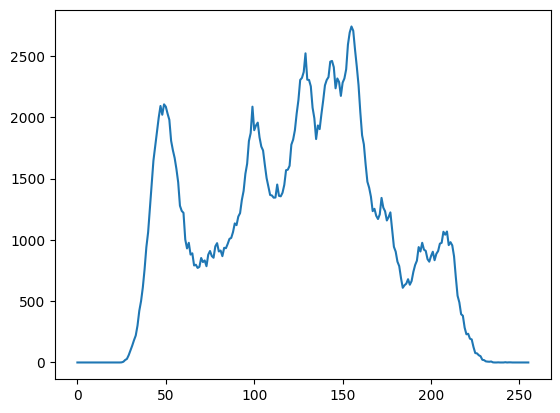

In [3]:
path_to_file = 'data_img/Lenna.png'
img = cv2.imread(path_to_file) # Откроем как полутоновое
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
hist = cv2.calcHist([img_gray],[0], None,[256],[0,256])
plt.plot(hist)

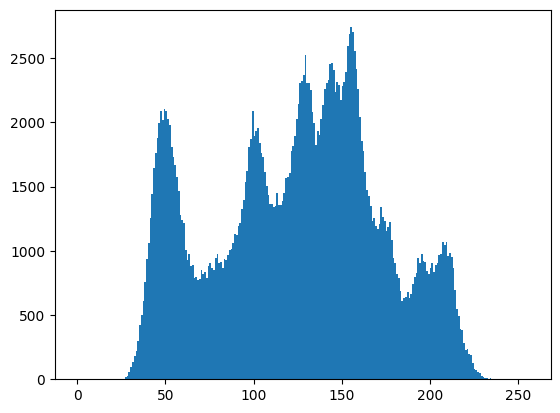

In [4]:
plt.hist(img_gray.ravel(), 256, [0,256])
plt.show()


C:\Users\reino\AppData\Local\Temp\ipykernel_6452\284383687.py:40: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right')


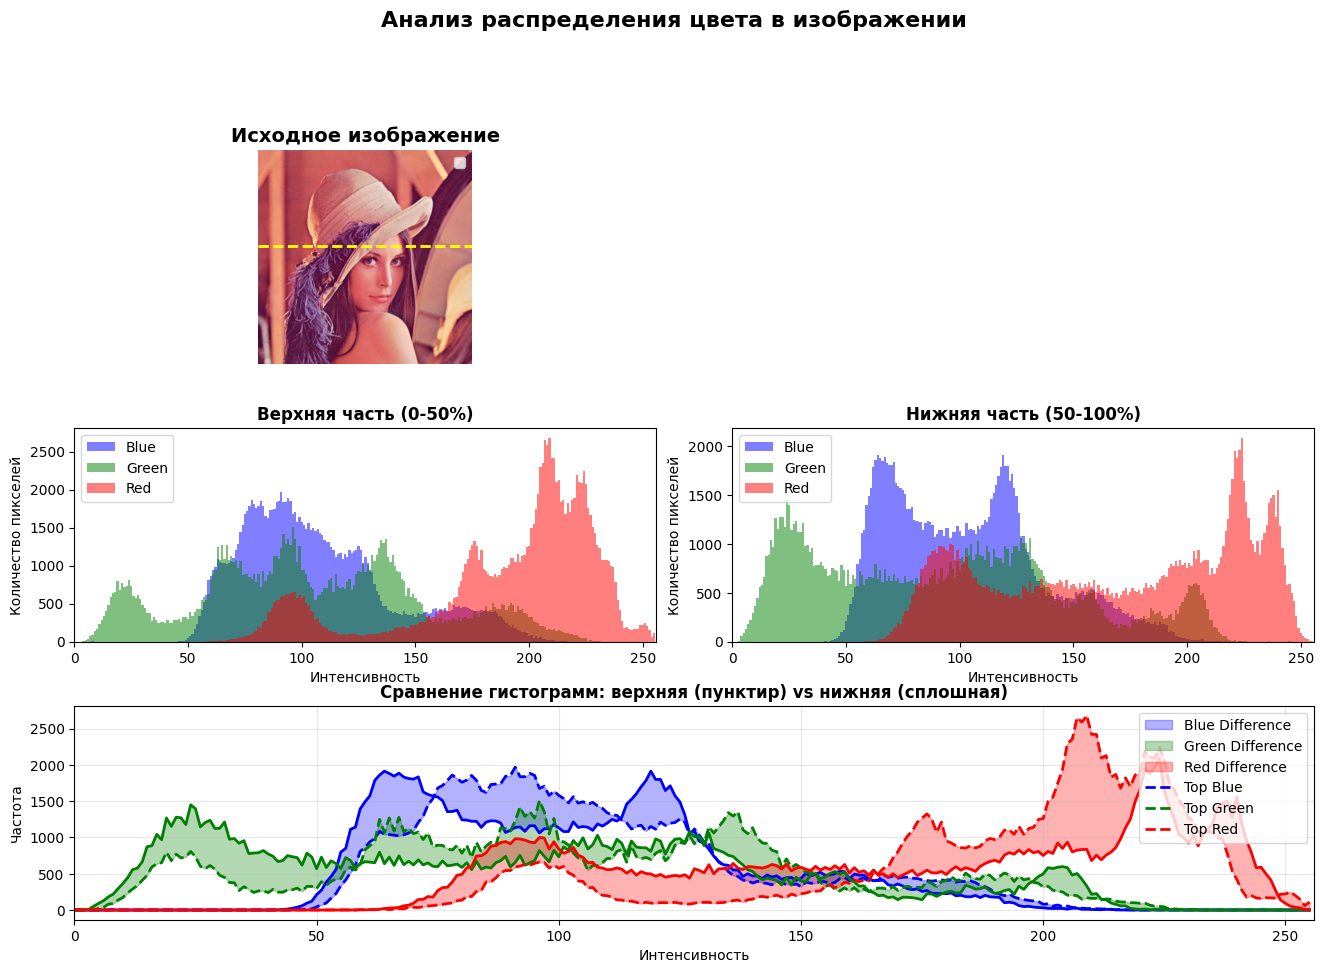

In [5]:
from matplotlib.gridspec import GridSpec
img = cv2.imread(path_to_file)
h, w = img.shape[:2]
b, g, r = cv2.split(img)

# Маски для верхней и нижней части
mask_top = np.zeros((h, w), dtype=np.uint8)
mask_top[:int(h*0.5), :] = 255

mask_bottom = np.zeros((h, w), dtype=np.uint8)
mask_bottom[int(h*0.5):, :] = 255

# Расчет гистограмм
hist_b_top = cv2.calcHist([b], [0], mask_top, [256], [0,256])
hist_g_top = cv2.calcHist([g], [0], mask_top, [256], [0,256])
hist_r_top = cv2.calcHist([r], [0], mask_top, [256], [0,256])

hist_b_bottom = cv2.calcHist([b], [0], mask_bottom, [256], [0,256])
hist_g_bottom = cv2.calcHist([g], [0], mask_bottom, [256], [0,256])
hist_r_bottom = cv2.calcHist([r], [0], mask_bottom, [256], [0,256])

# Нормализация гистограмм для сравнения
hist_b_top_norm = hist_b_top / hist_b_top.sum()
hist_b_bottom_norm = hist_b_bottom / hist_b_bottom.sum()
hist_g_top_norm = hist_g_top / hist_g_top.sum()
hist_g_bottom_norm = hist_g_bottom / hist_g_bottom.sum()
hist_r_top_norm = hist_r_top / hist_r_top.sum()
hist_r_bottom_norm = hist_r_bottom / hist_r_bottom.sum()

# Создание фигуры с GridSpec для гибкой компоновки
fig = plt.figure(figsize=(16, 10))
gs = GridSpec(3, 4, figure=fig, hspace=0.3, wspace=0.3)

# 1. Исходное изображение с разделительной линией
ax1 = fig.add_subplot(gs[0, :2])
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.axhline(y=int(h*0.45), color='yellow', linestyle='--', linewidth=2)
plt.title('Исходное изображение', fontsize=14, fontweight='bold')
plt.legend(loc='upper right')
plt.axis('off')

# 2. Стак-гистограмма для верхней части
ax2 = fig.add_subplot(gs[1, :2])
plt.bar(np.arange(256), hist_b_top.flatten(), color='b', alpha=0.5, label='Blue', width=1)
plt.bar(np.arange(256), hist_g_top.flatten(), color='g', alpha=0.5, label='Green', width=1)
plt.bar(np.arange(256), hist_r_top.flatten(), color='r', alpha=0.5, label='Red', width=1)
plt.title('Верхняя часть (0-50%)', fontsize=12, fontweight='bold')
plt.xlabel('Интенсивность')
plt.ylabel('Количество пикселей')
plt.legend()
plt.xlim([0, 256])

# 3. Стак-гистограмма для нижней части
ax3 = fig.add_subplot(gs[1, 2:])
plt.bar(np.arange(256), hist_b_bottom.flatten(), color='b', alpha=0.5, label='Blue', width=1)
plt.bar(np.arange(256), hist_g_bottom.flatten(), color='g', alpha=0.5, label='Green', width=1)
plt.bar(np.arange(256), hist_r_bottom.flatten(), color='r', alpha=0.5, label='Red', width=1)
plt.title('Нижняя часть (50-100%)', fontsize=12, fontweight='bold')
plt.xlabel('Интенсивность')
plt.ylabel('Количество пикселей')
plt.legend()
plt.xlim([0, 256])

# 4. Сравнение каналов (линейный график с заполнением)
ax4 = fig.add_subplot(gs[2, :])
x = np.arange(256)
plt.fill_between(x, hist_b_top.flatten(), hist_b_bottom.flatten(), alpha=0.3, color='b', label='Blue Difference')
plt.fill_between(x, hist_g_top.flatten(), hist_g_bottom.flatten(), alpha=0.3, color='g', label='Green Difference')
plt.fill_between(x, hist_r_top.flatten(), hist_r_bottom.flatten(), alpha=0.3, color='r', label='Red Difference')
plt.plot(hist_b_top, 'b--', linewidth=2, label='Top Blue')
plt.plot(hist_b_bottom, 'b-', linewidth=2)
plt.plot(hist_g_top, 'g--', linewidth=2, label='Top Green')
plt.plot(hist_g_bottom, 'g-', linewidth=2)
plt.plot(hist_r_top, 'r--', linewidth=2, label='Top Red')
plt.plot(hist_r_bottom, 'r-', linewidth=2)
plt.title('Сравнение гистограмм: верхняя (пунктир) vs нижняя (сплошная)', fontsize=12, fontweight='bold')
plt.xlabel('Интенсивность')
plt.ylabel('Частота')
plt.legend(loc='upper right')
plt.xlim([0, 256])
plt.grid(True, alpha=0.3)


plt.suptitle('Анализ распределения цвета в изображении', fontsize=16, fontweight='bold', y=1.02)
plt.show()

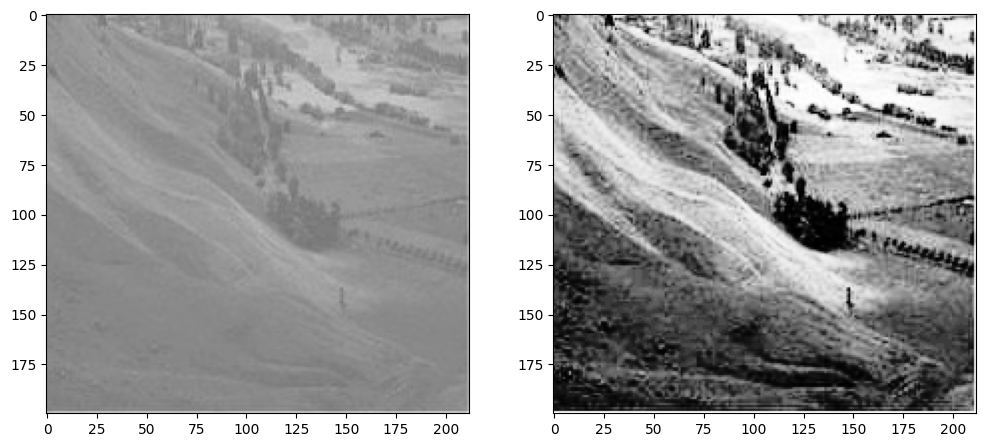

In [6]:
dark = "data_img/dark.jpg"
pict = cv2.imread(dark)
pict_yuv = cv2.cvtColor(pict, cv2.COLOR_BGR2YUV)
# Выровнять по каналу Y
pict_yuv[:,:,0] = cv2.equalizeHist(pict_yuv[:,:,0])
# Перевести в BGR схему
pict_output = cv2.cvtColor(pict_yuv, cv2.COLOR_YUV2BGR)
plt.figure(figsize = (12,6))
plt.subplot(121)
plt.imshow(cv2.cvtColor(pict, cv2.COLOR_BGR2RGB))
plt.subplot(122)
plt.imshow(cv2.cvtColor(pict_output, cv2.COLOR_BGR2RGB))


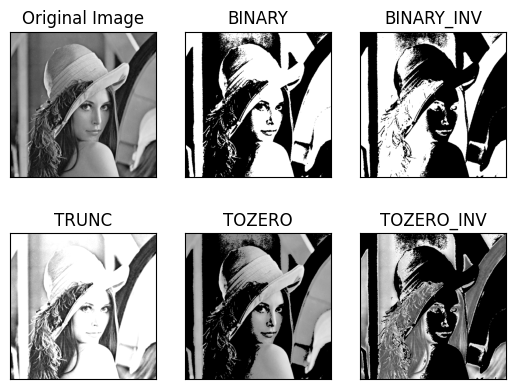

In [7]:
# пороговые, если больше 127 -> 255, иначе 0
ret,thresh1 = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY)
# инверсированный, если больше 127 -> 0, иначе 255
ret,thresh2 = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY_INV)
# Если больше 127, то 127, иначе без изменений
ret,thresh3 = cv2.threshold(img_gray, 127, 255, cv2.THRESH_TRUNC)
# Если меньше 127, то 0, иначе без изменений
ret,thresh4 = cv2.threshold(img_gray, 127, 255, cv2.THRESH_TOZERO)
# Если больше 127, то 0, иначе без изменений
ret,thresh5 = cv2.threshold(img_gray, 127, 255, cv2.THRESH_TOZERO_INV)

titles = ['Original Image','BINARY','BINARY_INV','TRUNC','TOZERO','TOZERO_INV']
images = [img_gray, thresh1, thresh2, thresh3, thresh4, thresh5]
for i in range(6):
    plt.subplot(2,3,i+1);plt.imshow(images[i], 'gray')
    plt.title(titles[i])
    plt.xticks([]);plt.yticks([])
plt.show()

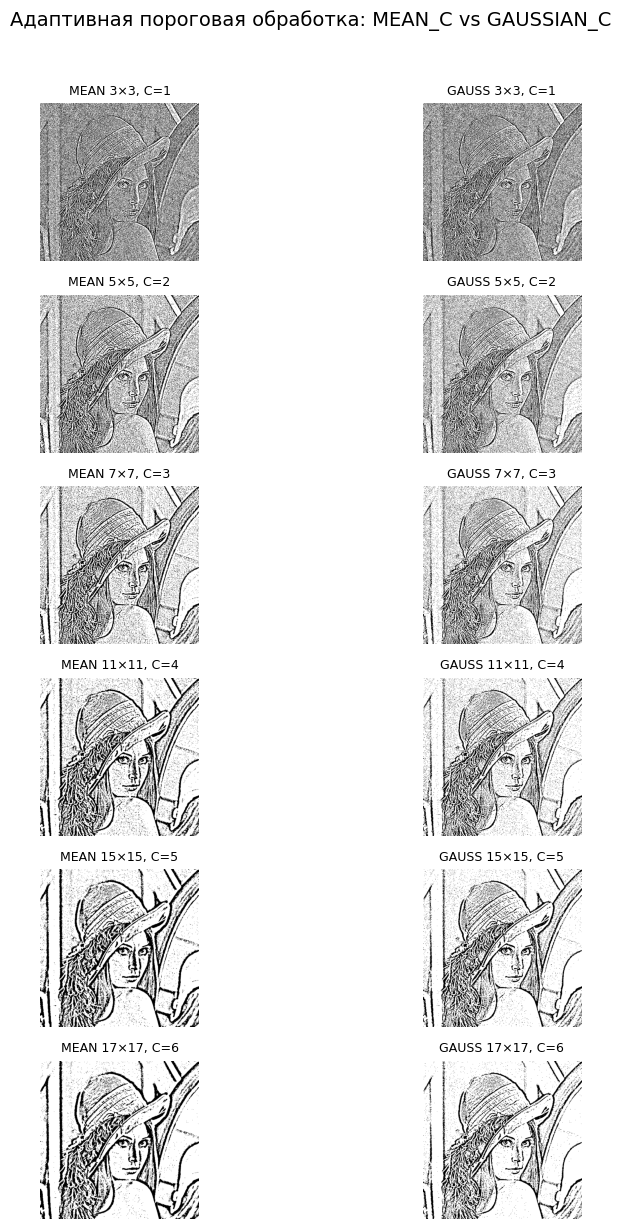

In [ ]:
# maxValue 255 Максимальное значение пикселя после порога
# adaptiveMethod MEAN_C / GAUSSIAN_C Метод вычисления порога
#   ADAPTIVE_THRESH_GAUSSIAN_C Вычисляет взвешенную сумму с гауссовым окном
#   ADAPTIVE_THRESH_MEAN_C Вычисляет среднее арифметическое значений пикселей в области blockSize×blockSize
# thresholdType THRESH_BINARY Тип пороговой обработки
# blockSize 11 Размер окрестности (нечётное число)
# C 2 Константа, вычитаемая из среднего/взвешенного

base_params = [
    (3, 1),
    (5, 2),
    (7, 3),
    (11, 4),
    (15, 5),
    (17, 6)
]

images = []
titles = []

for blockSize, c in base_params:
    # MEAN_C
    mean_img = cv2.adaptiveThreshold(img_gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C, 
                                      cv2.THRESH_BINARY, blockSize, c)
    images.append(mean_img)
    titles.append(f'MEAN {blockSize}×{blockSize}, C={c}')
    
    # GAUSSIAN_C
    gauss_img = cv2.adaptiveThreshold(img_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                       cv2.THRESH_BINARY, blockSize, c)
    images.append(gauss_img)
    titles.append(f'GAUSS {blockSize}×{blockSize}, C={c}')

plt.figure(figsize=(10, 12))
for i in range(len(images)):
    plt.subplot(6, 2, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i], fontsize=9)
    plt.axis('off')

plt.suptitle('Адаптивная пороговая обработка: MEAN_C vs GAUSSIAN_C', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

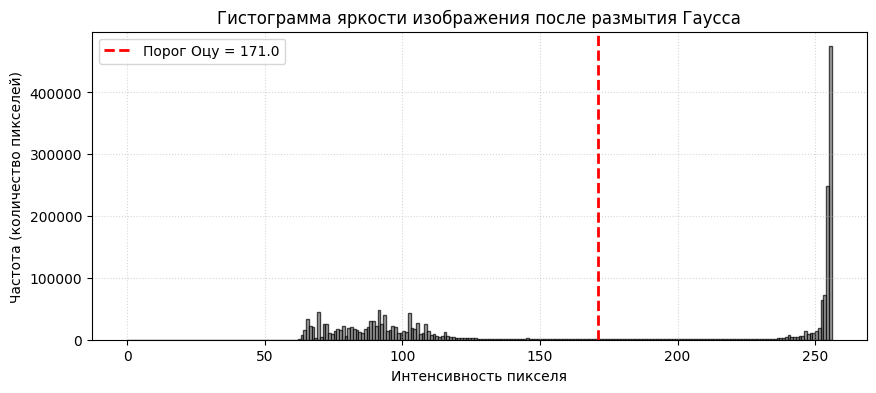

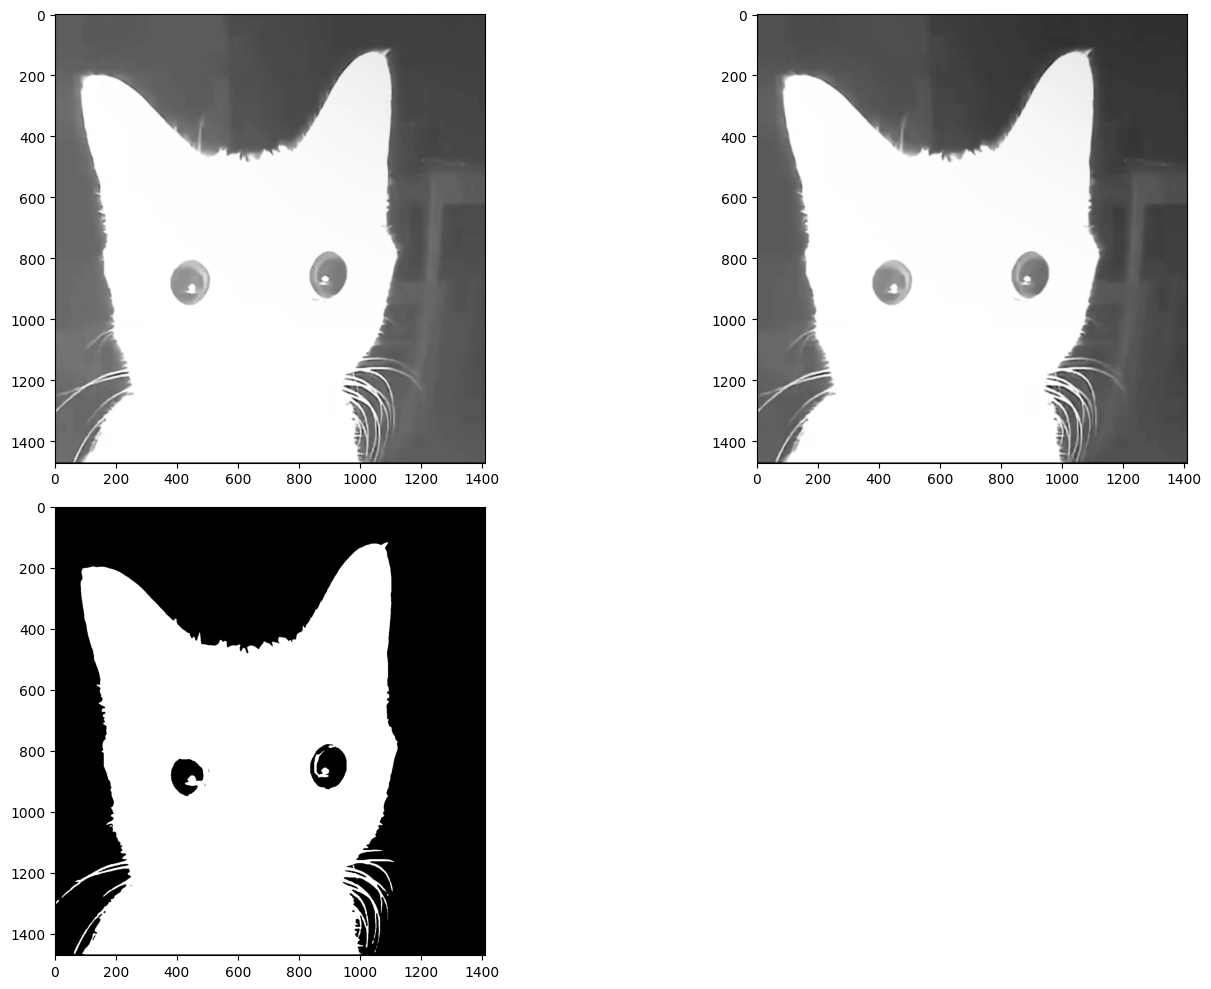

In [ ]:
img_color = cv2.imread('data_img/cat.jpg')
img_gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)

# Применяем фильтр Гаусса для сглаживания
blurred = cv2.GaussianBlur(img_gray, (5, 5), 0)

# Бинаризация методом Оцу
# Метод Оцу ищет порог, уменьшающий дисперсию внутри класса, которая определяется как взвешенная сумма дисперсий двух классов
ret_otsu, thresh_otsu = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt.figure(figsize=(10, 4))
plt.hist(blurred.ravel(), bins=256, range=[0, 256], color='gray', alpha=0.7, edgecolor='black')
plt.axvline(x=ret_otsu, color='red', linestyle='--', linewidth=2, label=f'Порог Оцу = {ret_otsu:.1f}')
plt.title('Гистограмма яркости изображения после размытия Гаусса')
plt.xlabel('Интенсивность пикселя')
plt.ylabel('Частота (количество пикселей)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

images = [img_gray, blurred, thresh_otsu]
titles = ['Исходное', 'После фильтра Гаусса', 'Оцу']


plt.figure(figsize=(15, 10))
for i, (img, title) in enumerate(zip(images, titles)):
    plt.subplot((len(images)+1)//2, 2, i+1)
    
    if len(img.shape) == 3:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(img, cmap='gray')
plt.tight_layout()
plt.show()